# REGRESION LINEAL MULTIPLE PARA PRECIO DE AUTO
## DATASET [kaggle](https://www.kaggle.com/datasets/mirichoi0218/insurance/data)

# PASO 1 - INSTALAMOS E IMPORTAMOS LIBRERIAS

In [1]:
!pip install pyjanitor
import janitor


[notice] A new release of pip available: 22.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

In [3]:
sns.set(style='whitegrid',context='notebook')

# PASO 2 CARGAMOS EL DATASET

In [4]:
df = pd.read_csv("D:\Conocimiento Adquiridos\Data Science _ Codigo Bootcamp\Desarrollo_MP\BDS-G3\Dia_2\car_price_dataset.csv")
df

<>:1: DeprecationWarning: invalid escape sequence '\C'
<>:1: DeprecationWarning: invalid escape sequence '\C'
C:\Users\ingma\AppData\Local\Temp\ipykernel_10556\1383061763.py:1: DeprecationWarning: invalid escape sequence '\C'
  df = pd.read_csv("D:\Conocimiento Adquiridos\Data Science _ Codigo Bootcamp\Desarrollo_MP\BDS-G3\Dia_2\car_price_dataset.csv")


,Brand,Model,Year,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count,Price
0,Kia,Rio,2020,4.2,Diesel,Manual,289944,3,5,8501
1,Chevrolet,Malibu,2012,2.0,Hybrid,Automatic,5356,2,3,12092
2,Mercedes,GLA,2020,4.2,Diesel,Automatic,231440,4,2,11171
3,Audi,Q5,2023,2.0,Electric,Manual,160971,2,1,11780
4,Volkswagen,Golf,2003,2.6,Hybrid,Semi-Automatic,286618,3,3,2867
...,...,...,...,...,...,...,...,...,...,...
9995,Kia,Optima,2004,3.7,Diesel,Semi-Automatic,5794,2,4,8884
9996,Chevrolet,Impala,2002,1.4,Electric,Automatic,168000,2,1,6240
9997,BMW,3 Series,2010,3.0,Petrol,Automatic,86664,5,1,9866
9998,Ford,Explorer,2002,1.4,Hybrid,Automatic,225772,4,1,4084


# PASO 3 : EDA

## VERIFICAMOS NULOS

In [5]:
df.isna().sum().sum()

0

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Brand         10000 non-null  object 
 1   Model         10000 non-null  object 
 2   Year          10000 non-null  int64  
 3   Engine_Size   10000 non-null  float64
 4   Fuel_Type     10000 non-null  object 
 5   Transmission  10000 non-null  object 
 6   Mileage       10000 non-null  int64  
 7   Doors         10000 non-null  int64  
 8   Owner_Count   10000 non-null  int64  
 9   Price         10000 non-null  int64  
dtypes: float64(1), int64(5), object(4)
memory usage: 781.4+ KB


##  ELIMINAMOS OUTLIERS

In [7]:
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

In [8]:
df_cleaned = remove_outliers(df,'Mileage')
df_cleaned = remove_outliers(df_cleaned,'Price')

df_cleaned.shape

(9994, 10)

# PASO 4 : CODIFICACIÓN DE VARIABLES CATEGORICAS

## IDENTIFICAMOS VARIABLES CATEGORICAS

In [9]:
df = df_cleaned
df.shape

(9994, 10)

In [10]:
categorical_columns = df.select_dtypes(object).columns
categorical_columns

Index(['Brand', 'Model', 'Fuel_Type', 'Transmission'], dtype='object')

# CREAMOS LISTA POR TIPO DE CODIFICACIÓN ( ORDINAL Y ONE HOT ENCODING)

In [11]:
for cc in categorical_columns:
  print("*"*50)
  print(df[cc].value_counts())

**************************************************
Ford          1047
Audi          1037
Volkswagen    1020
Honda         1007
Chevrolet     1003
BMW            999
Hyundai        994
Kia            976
Toyota         969
Mercedes       942
Name: Brand, dtype: int64
**************************************************
Accord      364
Fiesta      363
Impala      355
5 Series    353
Tiguan      352
Focus       351
Q5          350
A4          350
Elantra     346
Golf        339
A3          337
Civic       336
Optima      336
3 Series    335
Explorer    333
Malibu      333
Tucson      329
Passat      329
Rio         327
RAV4        324
Corolla     324
Camry       321
E-Class     321
Sonata      319
Equinox     315
GLA         315
Sportage    313
X5          311
CR-V        307
C-Class     306
Name: Model, dtype: int64
**************************************************
Electric    2621
Diesel      2512
Hybrid      2451
Petrol      2410
Name: Fuel_Type, dtype: int64
***************************

In [13]:
df_cleaned.drop(columns=['Model'],inplace=True)
categorical_columns = df_cleaned.select_dtypes(object).columns
categorical_columns

Index(['Brand', 'Fuel_Type', 'Transmission'], dtype='object')

## CREAMOS UN TRANSFORMER

In [14]:
import sklearn.compose
import sklearn.preprocessing
transformer = sklearn.compose.make_column_transformer(
    (sklearn.preprocessing.OneHotEncoder(),categorical_columns),
    remainder='passthrough'
)
transformer

ColumnTransformer(remainder='passthrough',
                  transformers=[('onehotencoder', OneHotEncoder(),
                                 Index(['Brand', 'Fuel_Type', 'Transmission'], dtype='object'))])

## APLICAMOS EL TRANSFOMER A LA VARIABLES CATEGORICAS

In [15]:
data_transformed_df = (
    pd.DataFrame(
        transformer.fit_transform(df_cleaned),
        columns = transformer.get_feature_names_out(),
        index=df_cleaned.index
    )
)

data_transformed_df = data_transformed_df.rename(
    columns=lambda x: x.replace("ordinalencoder__", "").replace("onehotencoder__", "").replace("remainder__", "")
)

data_transformed_df = data_transformed_df.clean_names()
data_transformed_df

,brand_audi,brand_bmw,brand_chevrolet,brand_ford,brand_honda,brand_hyundai,brand_kia,brand_mercedes,brand_toyota,brand_volkswagen,...,fuel_type_petrol,transmission_automatic,transmission_manual,transmission_semi_automatic,year,engine_size,mileage,doors,owner_count,price
0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,2020.0,4.2,289944.0,3.0,5.0,8501.0
1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,2012.0,2.0,5356.0,2.0,3.0,12092.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,2020.0,4.2,231440.0,4.0,2.0,11171.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,2023.0,2.0,160971.0,2.0,1.0,11780.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,2003.0,2.6,286618.0,3.0,3.0,2867.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,2004.0,3.7,5794.0,2.0,4.0,8884.0
9996,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,2002.0,1.4,168000.0,2.0,1.0,6240.0
9997,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,2010.0,3.0,86664.0,5.0,1.0,9866.0
9998,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,2002.0,1.4,225772.0,4.0,1.0,4084.0


In [16]:
corr_matrix = data_transformed_df.corr()
corr_charges = corr_matrix['price']
corr_charges.sort_values(ascending=False)

price                          1.000000
year                           0.662664
engine_size                    0.356057
transmission_automatic         0.243929
fuel_type_electric             0.225144
fuel_type_hybrid               0.047411
brand_chevrolet                0.018096
brand_mercedes                 0.013779
brand_volkswagen               0.008787
brand_audi                     0.007992
brand_kia                      0.003458
owner_count                    0.001812
brand_ford                    -0.000400
doors                         -0.001102
brand_toyota                  -0.006233
brand_hyundai                 -0.008382
brand_bmw                     -0.015388
brand_honda                   -0.021581
transmission_manual           -0.111230
transmission_semi_automatic   -0.132192
fuel_type_diesel              -0.136238
fuel_type_petrol              -0.141034
mileage                       -0.550270
Name: price, dtype: float64

<Axes: >

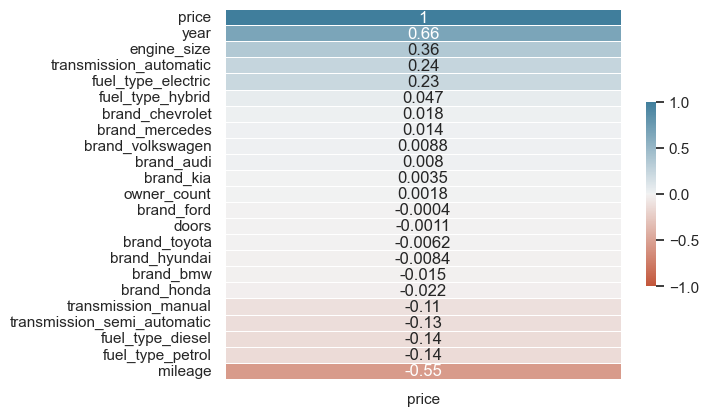

In [17]:
sns.heatmap(
    data=corr_charges.sort_values(ascending=False).to_frame(),
    cmap=sns.diverging_palette(20, 230, as_cmap=True),
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"shrink": 0.5},
    annot=True
)

# PASO 5 : CREACIÓN DEL MODELO DE MACHINE LEARNING

## DIVIDIMOS DATASET EN TRAIN Y TEST Y STANDARIZAMOS VALORES

In [18]:
X_cols = list(set(data_transformed_df.columns)-set(['price']))
y_col = ['price']

In [19]:
from sklearn.model_selection import train_test_split
import sklearn.metrics as metrics

X = data_transformed_df[X_cols].values
y = data_transformed_df[y_col].values

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

sc_x = StandardScaler()
X_train = sc_x.fit_transform(X_train)
X_test = sc_x.fit_transform(X_test)

sc_y = StandardScaler()
y_train = sc_y.fit_transform(y_train)
y_test = sc_y.fit_transform(y_test)

#creamos el modelo
model = LinearRegression()
model.fit(X_train,y_train)

y_pred = model.predict(X_test)


#erro cuadratico medio
mse = metrics.mean_squared_error(y_test,y_pred)
#R2 Coeficiente de determinación
r2 = metrics.r2_score(y_test,y_pred)

print(f'El error cuadratico medio(MSE) es de {round(mse,4)}')
print(f'El coeficiente de determinación(R2) es de {round(r2,4)}')

El error cuadratico medio(MSE) es de 4.3224757023558356e+20
El coeficiente de determinación(R2) es de -4.3224757023558356e+20


# HACEMOS AJUSTES PARA MEJORAR EL MODELO

## CODIFICAMOS TODAS LAS VARIABLES COMO ONEHOTENCODING

In [35]:
import sklearn.compose
import sklearn.preprocessing
transformer2 = sklearn.compose.make_column_transformer(
    (sklearn.preprocessing.OneHotEncoder(),['Fuel_Type','Transmission','Brand']),
    remainder='passthrough'
)
transformer2

ColumnTransformer(remainder='passthrough',
                  transformers=[('onehotencoder', OneHotEncoder(),
                                 ['Fuel_Type', 'Transmission', 'Brand'])])

In [36]:
data_transformed_df2 = (
    pd.DataFrame(
        transformer.fit_transform(df),
        columns = transformer.get_feature_names_out(),
        index=df_cleaned.index
    )
)

data_transformed_df2 = data_transformed_df.rename(
    columns=lambda x: x.replace("ordinalencoder__", "").replace("onehotencoder__", "").replace("remainder__", "")
)

data_transformed_df2 = data_transformed_df.clean_names()
data_transformed_df2

,brand_audi,brand_bmw,brand_chevrolet,brand_ford,brand_honda,brand_hyundai,brand_kia,brand_mercedes,brand_toyota,brand_volkswagen,...,fuel_type_petrol,transmission_automatic,transmission_manual,transmission_semi_automatic,year,engine_size,mileage,doors,owner_count,price
0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,2020.0,4.2,289944.0,3.0,5.0,8501.0
1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,2012.0,2.0,5356.0,2.0,3.0,12092.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,2020.0,4.2,231440.0,4.0,2.0,11171.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,2023.0,2.0,160971.0,2.0,1.0,11780.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,2003.0,2.6,286618.0,3.0,3.0,2867.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,2004.0,3.7,5794.0,2.0,4.0,8884.0
9996,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,2002.0,1.4,168000.0,2.0,1.0,6240.0
9997,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,2010.0,3.0,86664.0,5.0,1.0,9866.0
9998,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,2002.0,1.4,225772.0,4.0,1.0,4084.0


In [38]:
corr_matrix = data_transformed_df2.corr()
corr_charges = corr_matrix["price"]
corr_charges.sort_values(ascending=False)

price                          1.000000
year                           0.662664
engine_size                    0.356057
transmission_automatic         0.243929
fuel_type_electric             0.225144
fuel_type_hybrid               0.047411
brand_chevrolet                0.018096
brand_mercedes                 0.013779
brand_volkswagen               0.008787
brand_audi                     0.007992
brand_kia                      0.003458
owner_count                    0.001812
brand_ford                    -0.000400
doors                         -0.001102
brand_toyota                  -0.006233
brand_hyundai                 -0.008382
brand_bmw                     -0.015388
brand_honda                   -0.021581
transmission_manual           -0.111230
transmission_semi_automatic   -0.132192
fuel_type_diesel              -0.136238
fuel_type_petrol              -0.141034
mileage                       -0.550270
Name: price, dtype: float64

<Axes: >

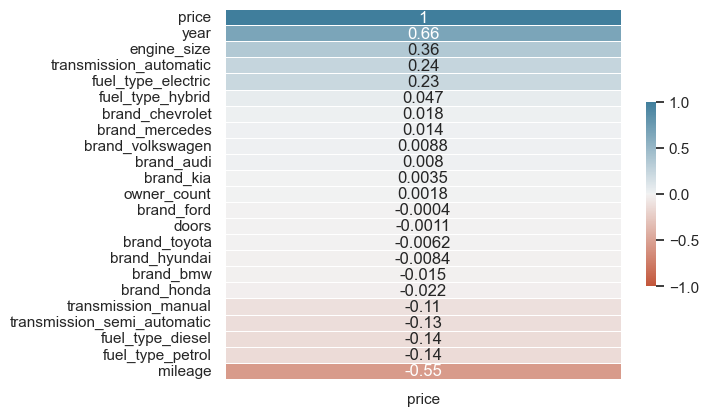

In [39]:
sns.heatmap(
    data=corr_charges.sort_values(ascending=False).to_frame(),
    cmap=sns.diverging_palette(20, 230, as_cmap=True),
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"shrink": 0.5},
    annot=True
)

## ENTRENAMOS NUEVAMENTE EL MODELO CON LOS CAMBIOS

## ESCOGEMOS LAS VARIABLES MAS RELEVANTES

In [42]:
#X_cols = list(set(data_transformed_df2.columns)-set(['charges']))
X_cols = ['year','engine_size','transmission_automatic','fuel_type_electric','fuel_type_hybrid']
y_col = ['price']

In [43]:
from sklearn.model_selection import train_test_split
import sklearn.metrics as metrics

X = data_transformed_df2[X_cols].values
y = data_transformed_df2[y_col].values

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

sc_x = StandardScaler()
X_train = sc_x.fit_transform(X_train)
X_test = sc_x.fit_transform(X_test)

sc_y = StandardScaler()
y_train = sc_y.fit_transform(y_train)
y_test = sc_y.fit_transform(y_test)

#creamos el modelo
model = LinearRegression()
model.fit(X_train,y_train)

y_pred = model.predict(X_test)


#erro cuadratico medio
mse = metrics.mean_squared_error(y_test,y_pred)
#R2 Coeficiente de determinación
r2 = metrics.r2_score(y_test,y_pred)

print(f'El error cuadratico medio(MSE) es de {round(mse,4)}')
print(f'El coeficiente de determinación(R2) es de {round(r2,4)}')

El error cuadratico medio(MSE) es de 0.3112
El coeficiente de determinación(R2) es de 0.6888


# GRAFICAMOS VALORES REALES CON VALORES PREDECIDOS

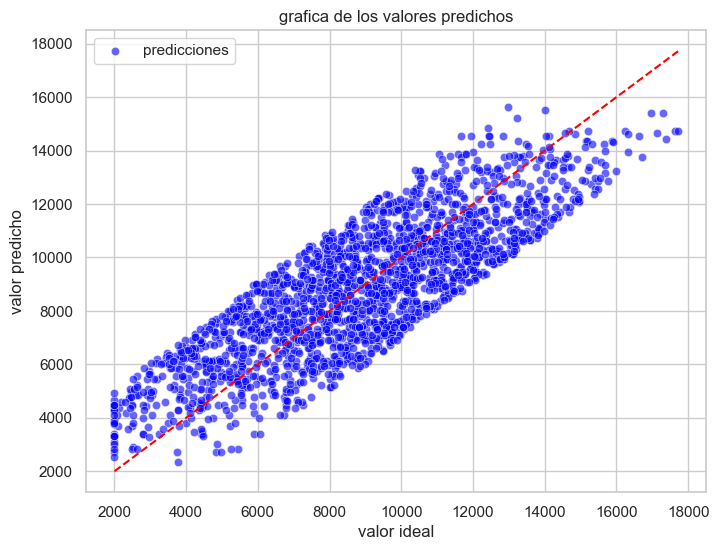

In [44]:
y_test_inv = sc_y.inverse_transform(y_test)
y_pred_inv = sc_y.inverse_transform(y_pred)

plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test_inv.flatten(),y=y_pred_inv.flatten(),alpha=0.6,color='blue',label='predicciones')
plt.plot([min(y_test_inv),max(y_test_inv)],[min(y_test_inv),max(y_test_inv)],color='red',linestyle='--')

plt.xlabel("valor ideal")
plt.ylabel("valor predicho")
plt.title("grafica de los valores predichos")
plt.legend()
plt.show()

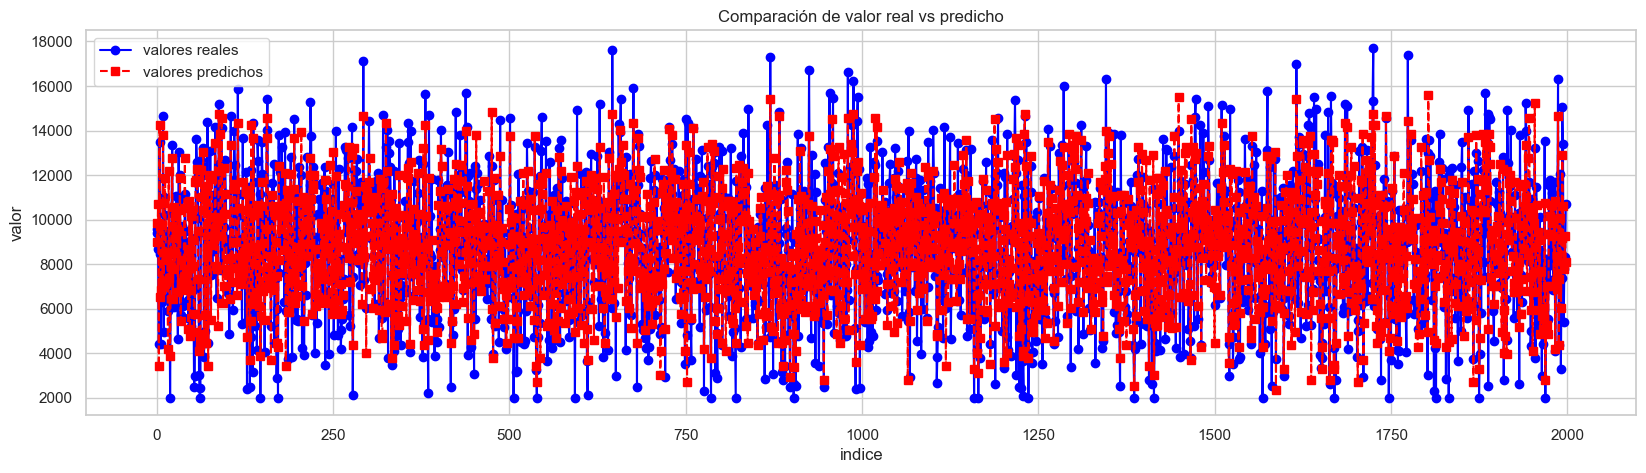

In [45]:
y_test_inv = sc_y.inverse_transform(y_test)
y_pred_inv = sc_y.inverse_transform(y_pred)


plt.figure(figsize=(20,5))
plt.plot(y_test_inv.flatten(),label='valores reales',marker='o',linestyle='-',color='blue')
plt.plot(y_pred_inv.flatten(),label='valores predichos',marker='s',linestyle='--',color='red')


plt.xlabel("indice")
plt.ylabel("valor")
plt.title("Comparación de valor real vs predicho")
plt.legend()
plt.grid(True)
plt.show()
